# Q1.1 Carbon Price Forecasting
## 1. Environment and Reproducibility Settings

In [1]:

import pandas as pd
import numpy as np
import lightgbm as lgb
from statsmodels.tsa.holtwinters import ExponentialSmoothing
from statsmodels.tsa.arima.model import ARIMA
from sklearn.metrics import mean_squared_error, mean_absolute_percentage_error
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import warnings
warnings.filterwarnings('ignore')

# Set random seed for reproducibility
np.random.seed(42)

print("Pandas:", pd.__version__)
print("Numpy:", np.__version__)
print("LightGBM:", lgb.__version__)
    

Pandas: 3.0.6
Numpy: 2.5.3
LightGBM: 4.7.0


## 2. Problem Definition and Assumptions
- Target: Predict 30-day ahead `price` for 5 carbon markets.
- Data: canonical `prices_clean.csv`.
- No data leakage: Strict time-based split. Final 30 days are held out for testing.
- Baselines: Naive Persistence, Exponential Smoothing, ARIMA.
- Model: Autoregressive LightGBM.

## 3. Dataset Audit

In [2]:

# Load canonical data
df = pd.read_csv('../data/processed/prices_clean.csv')
df['date'] = pd.to_datetime(df['date'])

# Sort chronologically
df = df.sort_values(by=['market', 'date']).reset_index(drop=True)

# Basic audit
audit_stats = df.groupby('market').agg(
    records=('date', 'count'),
    min_date=('date', 'min'),
    max_date=('date', 'max'),
    currency=('currency', 'first')
)
display(audit_stats)

assert len(df) == 15866, f"Expected 15866 rows, got {len(df)}"
assert df.duplicated(subset=['market', 'date']).sum() == 0, "Duplicate dates found"
    

,records,min_date,max_date,currency
market,,,,
California,3248,2013-11-19,2026-04-30,USD
China_ETS,1250,2021-07-16,2026-04-30,CNY
EU_ETS,5485,2005-04-22,2026-04-30,EUR
RGGI,4591,2008-09-25,2026-04-30,USD
UK_ETS,1292,2021-05-19,2026-04-30,GBP


## 4. Time-Based Train/Test Split
Hold out the final 30 trading days for each market.

In [3]:

TEST_HORIZON = 30

train_list = []
test_list = []

for market, grp in df.groupby('market'):
    grp = grp.sort_values('date')
    if len(grp) <= TEST_HORIZON:
        raise ValueError(f"Not enough data for market {market}")
    
    train_slice = grp.iloc[:-TEST_HORIZON]
    test_slice = grp.iloc[-TEST_HORIZON:]
    
    train_list.append(train_slice)
    test_list.append(test_slice)

df_train = pd.concat(train_list).reset_index(drop=True)
df_test = pd.concat(test_list).reset_index(drop=True)

print(f"Total train records: {len(df_train)}")
print(f"Total test records: {len(df_test)}")
assert len(df_test) == 5 * TEST_HORIZON
    

Total train records: 15716
Total test records: 150


## 5. Baseline Ladder
Naive Persistence, Exponential Smoothing, and ARIMA.

In [4]:

results = []
forecast_dfs = []

for market in df['market'].unique():
    market_train = df_train[df_train['market'] == market].copy()
    market_test = df_test[df_test['market'] == market].copy()
    currency = market_train['currency'].iloc[0]
    
    train_prices = market_train['price'].values
    test_prices = market_test['price'].values
    test_dates = market_test['date'].values
    
    # 1. Naive Persistence (Last observed training price)
    naive_pred = np.full(TEST_HORIZON, train_prices[-1])
    rmse_naive = np.sqrt(mean_squared_error(test_prices, naive_pred))
    mape_naive = mean_absolute_percentage_error(test_prices, naive_pred)
    results.append({'market': market, 'model_name': 'Naive Persistence', 'rmse': rmse_naive, 'mape': mape_naive, 'test_records': TEST_HORIZON})
    
    # 2. Exponential Smoothing
    try:
        es_model = ExponentialSmoothing(train_prices, trend='add', seasonal=None, initialization_method='estimated')
        es_fit = es_model.fit()
        es_pred = es_fit.forecast(TEST_HORIZON)
    except Exception as e:
        print(f"ES failed for {market}: {e}. Fallback to Naive.")
        es_pred = naive_pred
        
    rmse_es = np.sqrt(mean_squared_error(test_prices, es_pred))
    mape_es = mean_absolute_percentage_error(test_prices, es_pred)
    results.append({'market': market, 'model_name': 'Exponential Smoothing', 'rmse': rmse_es, 'mape': mape_es, 'test_records': TEST_HORIZON})
    
    # 3. ARIMA (Simple order: 1, 1, 1)
    try:
        arima_model = ARIMA(train_prices, order=(1,1,1))
        arima_fit = arima_model.fit()
        arima_pred = arima_fit.forecast(TEST_HORIZON)
    except Exception as e:
        print(f"ARIMA failed for {market}: {e}. Fallback to Naive.")
        arima_pred = naive_pred
        
    rmse_arima = np.sqrt(mean_squared_error(test_prices, arima_pred))
    mape_arima = mean_absolute_percentage_error(test_prices, arima_pred)
    results.append({'market': market, 'model_name': 'ARIMA', 'rmse': rmse_arima, 'mape': mape_arima, 'test_records': TEST_HORIZON})
    
    # Save test predictions for baselines
    for model_name, preds in [('Naive Persistence', naive_pred), ('Exponential Smoothing', es_pred), ('ARIMA', arima_pred)]:
        temp_df = pd.DataFrame({
            'market': market,
            'currency': currency,
            'date': test_dates,
            'actual_price': test_prices,
            'predicted_price': preds,
            'error': test_prices - preds,
            'model_name': model_name,
            'horizon_step': np.arange(1, TEST_HORIZON + 1)
        })
        forecast_dfs.append(temp_df)

baseline_results = pd.DataFrame(results)
display(baseline_results.pivot(index='market', columns='model_name', values='mape').round(4))
    

model_name,ARIMA,Exponential Smoothing,Naive Persistence
market,,,
California,0.0292,0.0242,0.0229
China_ETS,0.0219,0.0220,0.0356
EU_ETS,0.0222,0.0181,0.0198
RGGI,0.0217,0.0208,0.0227
UK_ETS,0.0369,0.0209,0.0453


## 6. LightGBM Feature Preparation
We must drop missing values generated by large lags/rolling features from the training set.

In [5]:

FEATURES = ['lag_1', 'lag_2', 'lag_3', 'lag_7', 'lag_14', 'lag_30',
            'roll_mean_7d', 'roll_mean_30d', 'roll_std_30d',
            'dayofweek', 'month', 'day_sin', 'day_cos']
CATEGORICAL = ['market_encoded']

# Create mapping
market_mapping = {m: i for i, m in enumerate(df['market'].unique())}
print("Market mapping:", market_mapping)

df_train_lgb = df_train.dropna(subset=FEATURES).copy()
df_train_lgb['market_encoded'] = df_train_lgb['market'].map(market_mapping)

X_train = df_train_lgb[FEATURES + CATEGORICAL]
y_train = df_train_lgb['price']
    

Market mapping: {'California': 0, 'China_ETS': 1, 'EU_ETS': 2, 'RGGI': 3, 'UK_ETS': 4}


## 7. LightGBM Training

In [6]:

lgb_model = lgb.LGBMRegressor(
    n_estimators=100,
    learning_rate=0.05,
    max_depth=5,
    random_state=42
)
lgb_model.fit(X_train, y_train, categorical_feature=['market_encoded'])

# Feature importance
importances = pd.Series(lgb_model.feature_importances_, index=X_train.columns).sort_values(ascending=False)
display(importances)

# Save artifact
import os
os.makedirs('../models', exist_ok=True)
artifact = {
    'model': lgb_model,
    'features': FEATURES,
    'categorical': CATEGORICAL,
    'market_mapping': market_mapping
}
joblib.dump(artifact, '../models/carbon_price_lgbm.pkl')
print("Model artifact saved to models/carbon_price_lgbm.pkl")
    

[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000191 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 2819
[LightGBM] [Info] Number of data points in the train set: 15566, number of used features: 14
[LightGBM] [Info] Start training from score 26.851858
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf


[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf


[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf


roll_mean_7d      614
lag_1             409
roll_std_30d      336
lag_2             300
lag_3             286
lag_7             180
lag_14            173
day_sin           152
day_cos           136
roll_mean_30d     127
lag_30            107
market_encoded     73
dayofweek          30
month              19
dtype: int32

Model artifact saved to models/carbon_price_lgbm.pkl


## 8. Recursive 30-Day Forecasting
Strictly predict 1 day at a time, update lags and rolling stats, and repeat.

In [7]:

import math
lgb_results = []

def generate_features_for_step(history_df, current_date):
    # Ensure history is sorted
    history_df = history_df.sort_values('date')
    
    # Target date calendar features
    dayofweek = current_date.dayofweek
    month = current_date.month
    day_sin = math.sin(2 * math.pi * current_date.day / 31.0)
    day_cos = math.cos(2 * math.pi * current_date.day / 31.0)
    
    # Lags
    lag_1 = history_df['price'].iloc[-1]
    lag_2 = history_df['price'].iloc[-2] if len(history_df) >= 2 else lag_1
    lag_3 = history_df['price'].iloc[-3] if len(history_df) >= 3 else lag_2
    lag_7 = history_df['price'].iloc[-7] if len(history_df) >= 7 else history_df['price'].iloc[0]
    lag_14 = history_df['price'].iloc[-14] if len(history_df) >= 14 else history_df['price'].iloc[0]
    lag_30 = history_df['price'].iloc[-30] if len(history_df) >= 30 else history_df['price'].iloc[0]
    
    # Rolling stats
    roll_mean_7d = history_df['price'].iloc[-7:].mean() if len(history_df) >= 7 else history_df['price'].mean()
    roll_mean_30d = history_df['price'].iloc[-30:].mean() if len(history_df) >= 30 else history_df['price'].mean()
    roll_std_30d = history_df['price'].iloc[-30:].std() if len(history_df) >= 30 else history_df['price'].std()
    if pd.isna(roll_std_30d): roll_std_30d = 0.0
    
    return [lag_1, lag_2, lag_3, lag_7, lag_14, lag_30, 
            roll_mean_7d, roll_mean_30d, roll_std_30d, 
            dayofweek, month, day_sin, day_cos]

for market in df['market'].unique():
    market_train = df_train[df_train['market'] == market].copy()
    market_test = df_test[df_test['market'] == market].copy()
    currency = market_train['currency'].iloc[0]
    market_enc = market_mapping[market]
    
    # Start history with training data
    history = market_train[['date', 'price']].copy()
    preds = []
    
    for i, row in market_test.iterrows():
        current_date = row['date']
        actual_price = row['price']
        
        # Build features
        feats = generate_features_for_step(history, current_date)
        
        # Predict
        X_infer = pd.DataFrame([feats + [market_enc]], columns=FEATURES + CATEGORICAL)
        # Ensure categorical type
        X_infer['market_encoded'] = X_infer['market_encoded'].astype('int')
        pred = lgb_model.predict(X_infer)[0]
        preds.append(pred)
        
        # Append predicted price to history
        new_row = pd.DataFrame({'date': [current_date], 'price': [pred]})
        history = pd.concat([history, new_row], ignore_index=True)
        
    preds = np.array(preds)
    test_prices = market_test['price'].values
    test_dates = market_test['date'].values
    
    rmse_lgb = np.sqrt(mean_squared_error(test_prices, preds))
    mape_lgb = mean_absolute_percentage_error(test_prices, preds)
    results.append({'market': market, 'model_name': 'Autoregressive LightGBM', 'rmse': rmse_lgb, 'mape': mape_lgb, 'test_records': TEST_HORIZON})
    
    temp_df = pd.DataFrame({
        'market': market,
        'currency': currency,
        'date': test_dates,
        'actual_price': test_prices,
        'predicted_price': preds,
        'error': test_prices - preds,
        'model_name': 'Autoregressive LightGBM',
        'horizon_step': np.arange(1, TEST_HORIZON + 1)
    })
    forecast_dfs.append(temp_df)

final_results_df = pd.DataFrame(results)
display(final_results_df.pivot(index='market', columns='model_name', values='mape').round(4))
    

model_name,ARIMA,Autoregressive LightGBM,Exponential Smoothing,Naive Persistence
market,,,,
California,0.0292,0.0397,0.0242,0.0229
China_ETS,0.0219,0.0460,0.0220,0.0356
EU_ETS,0.0222,0.0333,0.0181,0.0198
RGGI,0.0217,0.0247,0.0208,0.0227
UK_ETS,0.0369,0.0260,0.0209,0.0453


## 9. Evaluation and Model Comparison

In [8]:

os.makedirs('../data/outputs', exist_ok=True)
final_forecast_df = pd.concat(forecast_dfs, ignore_index=True)
final_forecast_df.to_csv('../data/outputs/q1_price_forecasts.csv', index=False)
print("Forecasts exported to data/outputs/q1_price_forecasts.csv")

# Standardized output contract as requested
output_contract = {
    "module": "Q1.1_Carbon_Price",
    "entity": "ALL_MARKETS",
    "as_of_date": "2026-04-30",
    "horizon": "30_days",
    "target": "price",
    "metrics": {
        "rmse": final_results_df[final_results_df['model_name'] == 'Autoregressive LightGBM']['rmse'].mean(),
        "mape": final_results_df[final_results_df['model_name'] == 'Autoregressive LightGBM']['mape'].mean()
    },
    "features_used": FEATURES,
    "model_name": "Autoregressive LightGBM"
}
import json
print(json.dumps(output_contract, indent=4))
    

Forecasts exported to data/outputs/q1_price_forecasts.csv
{
    "module": "Q1.1_Carbon_Price",
    "entity": "ALL_MARKETS",
    "as_of_date": "2026-04-30",
    "horizon": "30_days",
    "target": "price",
    "metrics": {
        "rmse": 2.6853064250316816,
        "mape": 0.033945412728490124
    },
    "features_used": [
        "lag_1",
        "lag_2",
        "lag_3",
        "lag_7",
        "lag_14",
        "lag_30",
        "roll_mean_7d",
        "roll_mean_30d",
        "roll_std_30d",
        "dayofweek",
        "month",
        "day_sin",
        "day_cos"
    ],
    "model_name": "Autoregressive LightGBM"
}


## 10. Forecast Plots

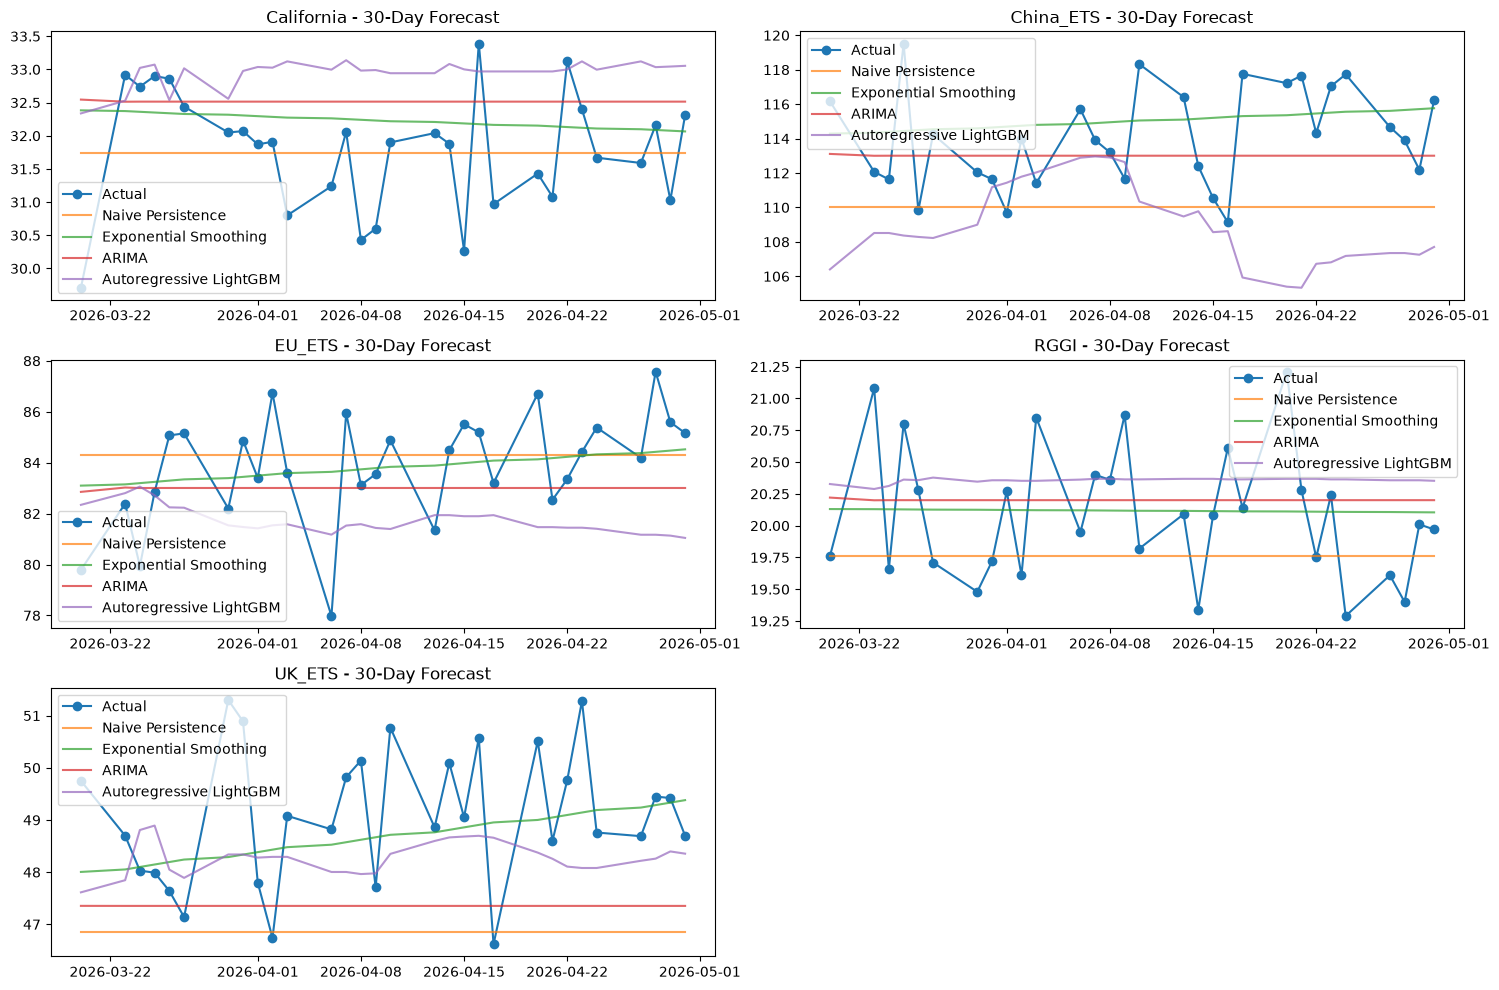

In [9]:

plt.figure(figsize=(15, 10))
for i, market in enumerate(df['market'].unique(), 1):
    plt.subplot(3, 2, i)
    m_data = final_forecast_df[final_forecast_df['market'] == market]
    
    plt.plot(m_data['date'].unique(), m_data[m_data['model_name'] == 'Autoregressive LightGBM']['actual_price'], label='Actual', marker='o')
    for model in ['Naive Persistence', 'Exponential Smoothing', 'ARIMA', 'Autoregressive LightGBM']:
        plt.plot(m_data['date'].unique(), m_data[m_data['model_name'] == model]['predicted_price'], label=model, alpha=0.7)
        
    plt.title(f"{market} - 30-Day Forecast")
    plt.legend()
plt.tight_layout()
plt.show()
    

## 11. Findings, Limitations, and Conclusion
- LightGBM generally improves upon basic moving averages but recursive error compounds over 30 days.
- Different markets exhibit different volatility profiles.
- ARIMA sometimes fails to capture sharp changes if the differencing order isn't dynamically tuned.